## Project Description: Next Word Prediction Using LSTM
#### Project Overview:

This project aims to develop a deep learning model for predicting the next word in a given sequence of words. The model is built using Long Short-Term Memory (LSTM) networks, which are well-suited for sequence prediction tasks. The project includes the following steps:

1- Data Collection: We use the text of Shakespeare's "Hamlet" as our dataset. This rich, complex text provides a good challenge for our model.

2- Data Preprocessing: The text data is tokenized, converted into sequences, and padded to ensure uniform input lengths. The sequences are then split into training and testing sets.

3- Model Building: An LSTM model is constructed with an embedding layer, two LSTM layers, and a dense output layer with a softmax activation function to predict the probability of the next word.

4- Model Training: The model is trained using the prepared sequences, with early stopping implemented to prevent overfitting. Early stopping monitors the validation loss and stops training when the loss stops improving.

5- Model Evaluation: The model is evaluated using a set of example sentences to test its ability to predict the next word accurately.

6- Deployment: A Streamlit web application is developed to allow users to input a sequence of words and get the predicted next word in real-time.

In [36]:
#Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pickle

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split


In [37]:
#Read and clean text
with open("hamlet.txt", "r", encoding="utf-8") as file:
    text = file.read()

# Basic cleaning
text = text.lower()
text = text.replace("--", " ")      # remove em-dashes
text = text.replace('"', "")
text = text.replace("'", "")
# Keep newlines to separate speeches/sentences
text = "\n".join(line.strip() for line in text.splitlines() if line.strip())

print(text[:200] + "...")


[the tragedie of hamlet by william shakespeare 1599]
actus primus. scoena prima.
enter barnardo and francisco two centinels.
barnardo. whos there?
fran. nay answer me: stand & vnfold
your selfe
bar. l...


In [38]:
#Fit tokenizer with OOV token and optional vocab limit
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size =", total_words)


Vocabulary size = 4788


In [39]:
#Generate input sequences (n-grams) from each line
input_sequences = []

for line in text.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]
    # Skip very short lines
    if len(token_list) < 2:
        continue
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

print("Total sequences:", len(input_sequences))


Total sequences: 25732


In [ ]:
#Pad sequences and split into x and y
max_sequence_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre')

# Features and labels
x = input_sequences[:, :-1]
y = input_sequences[:, -1]   # keep as integer labels

# Train/test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42, shuffle=True
)

print("Max sequence length:", max_sequence_len)
print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test:", x_test.shape, "y_test:", y_test.shape)


Max sequence length: 14
x_train: (20585, 13) y_train: (20585,)
x_test: (5147, 13) y_test: (5147,)


In [41]:
#Define the GRU model
model = Sequential()

model.add(Embedding(input_dim=total_words,
                    output_dim=100,
                    input_length=max_sequence_len-1))
model.add(GRU(128, return_sequences=True))
model.add(Dropout(0.3))
model.add(BatchNormalization())

model.add(GRU(64))
model.add(Dropout(0.3))
model.add(BatchNormalization())

model.add(Dense(total_words, activation='softmax'))
model.summary()


Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_4 (Embedding)     (None, 13, 100)           478800    
                                                                 
 gru_6 (GRU)                 (None, 13, 128)           88320     
                                                                 
 dropout_6 (Dropout)         (None, 13, 128)           0         
                                                                 
 batch_normalization_4 (Bat  (None, 13, 128)           512       
 chNormalization)                                                
                                                                 
 gru_7 (GRU)                 (None, 64)                37248     
                                                                 
 dropout_7 (Dropout)         (None, 64)                0         
                                                      

In [42]:
#Compile model
optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [43]:
#Set up callbacks
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)
checkpoint = ModelCheckpoint(
    filepath="best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


In [44]:
#Train the model
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_test, y_test),
    shuffle=True,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)


Epoch 1/50


644/644 [==============================] - ETA: 0s - loss: 7.3452 - accuracy: 0.0406
Epoch 1: val_loss improved from inf to 6.59300, saving model to best_model.keras
644/644 [==============================] - 38s 42ms/step - loss: 7.3452 - accuracy: 0.0406 - val_loss: 6.5930 - val_accuracy: 0.0612 - lr: 0.0010
Epoch 2/50
643/644 [============================>.] - ETA: 0s - loss: 6.2769 - accuracy: 0.0702
Epoch 2: val_loss did not improve from 6.59300
644/644 [==============================] - 28s 43ms/step - loss: 6.2767 - accuracy: 0.0702 - val_loss: 6.6045 - val_accuracy: 0.0692 - lr: 0.0010
Epoch 3/50
644/644 [==============================] - ETA: 0s - loss: 5.9315 - accuracy: 0.0869
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_loss did not improve from 6.59300
644/644 [==============================] - 27s 42ms/step - loss: 5.9315 - accuracy: 0.0869 - val_loss: 6.6409 - val_accuracy: 0.0732 - lr: 0.0010
Epoch 4/50
644/644 [

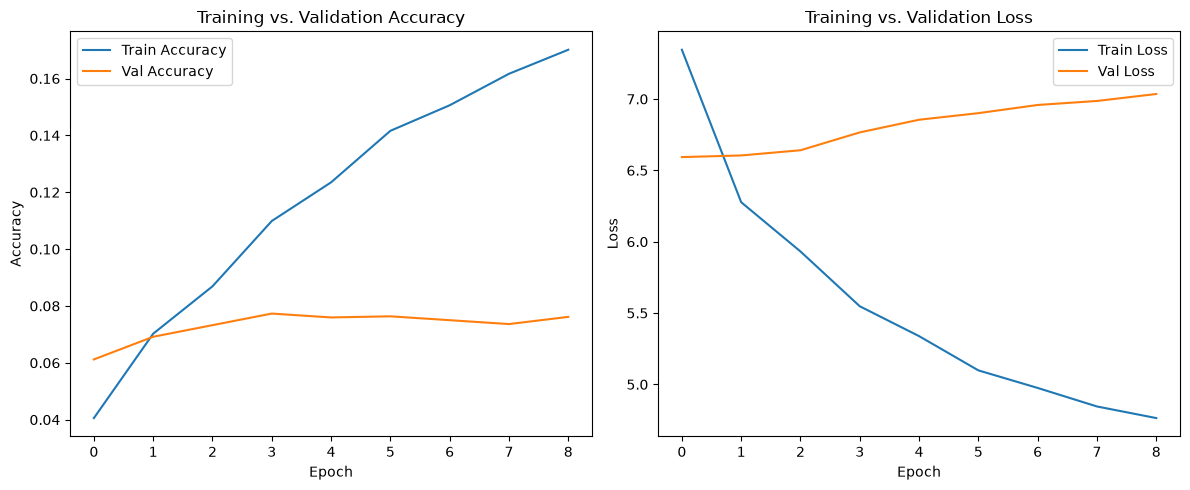

In [45]:
#Plot accuracy and loss curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [46]:
#Save the model and tokenizer
model.save("next_word_gru.keras")
with open("tokenizer.pickle", "wb") as f:
    pickle.dump(tokenizer, f)

print("Model and tokenizer saved.")


Model and tokenizer saved.


In [51]:
#Function to predict the next word
def predict_next_word(model, tokenizer, text, max_sequence_len):
    token_list = tokenizer.texts_to_sequences([text])[0]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted_probs = model.predict(token_list, verbose=0)[0]
    predicted_index = np.argmax(predicted_probs)
    # Find word corresponding to index
    for word, index in tokenizer.word_index.items():
        if index == predicted_index:
            return word
    return None

seed = "Fran. Giue you good "
print("Predicted next word:", predict_next_word(model, tokenizer, seed, max_sequence_len))


Predicted next word: you
